# 04 — Secondary Vertex / Set2Graph
## Gate de recuperabilidad del target supervisado
Este notebook presenta evidencia real del gate de datos. **No** muestra rendimiento de tagging: todavía no existe un target de vértice aprobado ni un modelo S2G entrenado.

In [1]:
from pathlib import Path
import hashlib, json, tomllib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'notebooks/evidencia.toml').is_file(): ROOT = ROOT.parent
if not (ROOT / 'notebooks/evidencia.toml').is_file(): raise FileNotFoundError('No se encontró notebooks/evidencia.toml.')
sha256 = lambda path: hashlib.sha256(path.read_bytes()).hexdigest()
entry = tomllib.loads((ROOT / 'notebooks/evidencia.toml').read_text())['s2g_target_preflight']
report_path = ROOT / entry['report']
if sha256(report_path) != entry['report_sha256']: raise ValueError('Raíz S2G preflight inválida.')
report = json.loads(report_path.read_text())
if report['status'] != 'GO_BOUNDED_DEVELOPMENT_AUDIT' or report['supervised_vertex_target_ready'] is not False: raise ValueError('El gate S2G no conserva su estado bloqueado.')
for evidence in report['evidence'].values():
    path = ROOT / evidence['path']
    if sha256(path) != evidence['sha256']: raise ValueError(f'Evidencia fuente S2G inválida: {path}.')
audit_entry = tomllib.loads((ROOT / 'notebooks/evidencia.toml').read_text())['s2g_vertex_audit']; audit_path = ROOT / audit_entry['report']
if sha256(audit_path) != audit_entry['report_sha256']: raise ValueError('Raíz de auditoría ROOT S2G inválida.')
vertex_audit = json.loads(audit_path.read_text())
if vertex_audit['status'] != 'REVIEW_REQUIRED' or vertex_audit['supervised_vertex_target_ready'] is not False: raise ValueError('La auditoría ROOT no conserva revisión pendiente.')

,fuentes inventariadas,tracks,referencias resueltas,inválidas/no resueltas,UID ambiguas,target listo
0,6,295039,295039,0,0,False


,ramas requeridas
0,Particle/Particle.D1
1,Particle/Particle.D2
2,Particle/Particle.M1
3,Particle/Particle.M2
4,Particle/Particle.PID
5,Particle/Particle.Status
6,Particle/Particle.T
7,Particle/Particle.X
8,Particle/Particle.Y
9,Particle/Particle.Z


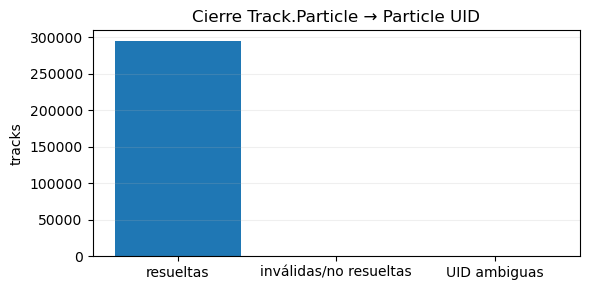

In [2]:
closure = report['track_particle_reference_closure']
display(pd.DataFrame([{'fuentes inventariadas': report['sources_inventoried'], 'tracks': closure['tracks'], 'referencias resueltas': closure['resolved_references'], 'inválidas/no resueltas': closure['unresolved_or_invalid'], 'UID ambiguas': closure['ambiguous_duplicate_uid_references'], 'target listo': report['supervised_vertex_target_ready']}]))
display(pd.DataFrame({'ramas requeridas': report['required_branches']}))
fig, ax = plt.subplots(figsize=(6, 3)); ax.bar(['resueltas', 'inválidas/no resueltas', 'UID ambiguas'], [closure['resolved_references'], closure['unresolved_or_invalid'], closure['ambiguous_duplicate_uid_references']]); ax.set(ylabel='tracks', title='Cierre Track.Particle → Particle UID'); ax.grid(axis='y', alpha=.2); plt.tight_layout(); plt.show()

In [3]:
aggregate = vertex_audit['aggregate']; tolerance = pd.Series(aggregate['same_vertex_pairs_by_tolerance_mm'], name='pares mismo vértice').rename_axis('tolerancia máxima |ΔX,Y,Z,T| [mm]').reset_index()
display(pd.DataFrame([{'eventos auditados': aggregate['events'], 'jets': aggregate['jets'], 'jets elegibles para pares': aggregate['pair_eligible_jets'], 'pares': aggregate['track_pairs'], 'tracks con ancestry': aggregate['tracks_with_ancestors'], 'referencias ancestry inválidas': aggregate['invalid_ancestry_references']}]))
display(tolerance); display(pd.DataFrame({'debe establecerse antes de entrenar': report['next_audit']['must_establish']})); display(pd.DataFrame({'atajos prohibidos': report['next_audit']['forbidden_shortcuts']}))

,eventos auditados,jets,jets elegibles para pares,pares,tracks con ancestry,referencias ancestry inválidas
0,600,2182,1097,3244,3691,0


,"tolerancia máxima |ΔX,Y,Z,T| [mm]",pares mismo vértice
0,0,2229
1,0.0001,2320
2,0.01,2337
3,1e-06,2289


,debe establecerse antes de entrenar
0,Delphes Particle.M1/M2 ancestry semantics and ...
1,whether shared Particle.X/Y/Z/T identifies sim...
2,primary versus displaced and b-to-c cascade tr...
3,track-to-jet alignment with the existing Delta...
4,pair-target permutation invariance and degener...


,atajos prohibidos
0,d0/dz proximity as truth vertex identity
1,Particle array position or Track.Particle raw ...
2,"jet flavor, source, run, file name or candidat..."


## Decisión actual
Las referencias `Track.Particle → Particle.fUniqueID` tienen cierre completo en la evidencia piloto y existen ramas de ancestry y producción. Eso habilita una auditoría ROOT acotada sobre desarrollo.

La auditoría ROOT acotada revisó 600 eventos: 3.691 tracks asociados tienen ancestry y no aparecieron referencias M1/M2 inválidas. De 3.244 pares elegibles, 2.229 comparten exactamente X/Y/Z/T y 2.337 lo hacen a tolerancia 0,01 mm; la sensibilidad a tolerancia es visible y aún no define una etiqueta.

El entrenamiento S2G permanece **bloqueado** hasta congelar semántica de vértice, cascadas b→c, tolerancia, permutaciones y casos degenerados. Vertex F1/RI/ARI no se presentarán como eficiencia de b-tagging.